# Clasificación Zero-Shot con Gemini 2.0 Flash Lite

Este notebook evalúa el rendimiento de un modelo multimodal (**Gemini 2.0 Flash Lite**, accedido vía OpenRouter) en una tarea de **clasificación binaria zero-shot** sobre imágenes de un escáner biométrico.

**Objetivo:** determinar si el dedo está correctamente colocado sobre la barra de luz del escáner (clase `SI`) o no (clase `NO`), sin entrenamiento previo del modelo sobre este dominio.

**Pipeline:**
1. Configuración del cliente y verificación de conexión
2. Utilidades de preprocesamiento de imágenes
3. Diseño de prompts zero-shot
4. Inferencia sobre el conjunto de evaluación (70 imágenes)
5. Cálculo de métricas y matriz de confusión

**Resultado global obtenido:** *Accuracy* = **70.00%** sobre 70 imágenes evaluadas.

## 1. Instalación de dependencias

Librerías necesarias: cliente OpenAI compatible (para OpenRouter), Pillow para manipulación de imágenes y `requests` para descargas remotas.

In [ ]:
# !pip install openai pillow requests

## 2. Configuración del cliente OpenRouter

Se carga la API key desde el archivo `.env` y se inicializa el cliente apuntando al endpoint de OpenRouter. El modelo seleccionado es `google/gemini-2.0-flash-lite-001`.

In [ ]:
import os
from dotenv import load_dotenv
from openai import OpenAI
import base64, requests
from io import BytesIO
from PIL import Image

load_dotenv(".env")  # o solo load_dotenv() si está en el mismo directorio

OPENROUTER_API_KEY = os.environ.get("OPENROUTER_API_KEY")

if not OPENROUTER_API_KEY:
    raise ValueError("No se encontró OPENROUTER_API_KEY en el .env")

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY,
)

MODEL = "google/gemini-2.0-flash-lite-001"
print("Cliente OpenRouter configurado")

Cliente OpenRouter configurado


### 2.1 Verificación de conexión

Petición simple de texto para confirmar que el cliente está correctamente configurado y el modelo responde antes de pasar a la inferencia multimodal.

In [ ]:
response = client.chat.completions.create(
    model=MODEL,
    messages=[
        {"role": "user", "content": "Di 'conexión OK' y el modelo que eres."}
    ]
)

print(response.choices[0].message.content)

conexión OK

Soy un modelo de lenguaje, entrenado por Google.



## 3. Preprocesamiento de imágenes

Función auxiliar para convertir imágenes a `base64`, requisito del endpoint multimodal. Acepta rutas locales, URLs o instancias de `PIL.Image`, y normaliza el modo de color a RGB para evitar errores con PNGs en formato RGBA.

In [ ]:
def image_to_base64(source, format="JPEG"):
    """
    Convierte imagen a base64.
    source: ruta local (str) | URL (str) | PIL.Image
    """
    if isinstance(source, str) and source.startswith("http"):
        img_data = requests.get(source).content
        img = Image.open(BytesIO(img_data))
    elif isinstance(source, str):
        img = Image.open(source)
    else:
        img = source  # PIL Image directamente

    # Convertir a RGB si hace falta (evita errores con PNG RGBA)
    if img.mode in ("RGBA", "P"):
        img = img.convert("RGB")

    buffer = BytesIO()
    img.save(buffer, format=format)
    b64 = base64.b64encode(buffer.getvalue()).decode("utf-8")
    mime = f"image/{format.lower()}"
    return b64, mime

## 4. Carga del dataset

Búsqueda automática del directorio `imagenes_procesadas` y selección de una muestra aleatoria para inspección visual. La estructura esperada es `train/{si,no}` y `test/{si,no}`.

Imagen seleccionada: c:\Users\FadouaHt\Documents\DocumentosCurso\ProyectoFinal_CSEBDIA\CNN_desde_0\imagenes_procesadas\train\si\img_1777027197915.png
Clase: si


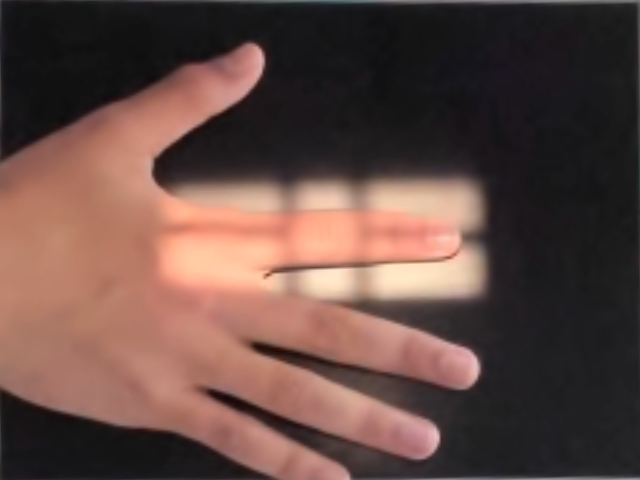

In [ ]:
import os
import random
from pathlib import Path
from IPython.display import display, Image as IPImage

# --- Localizar imagenes_procesadas buscando hacia arriba ---
def find_imagenes_procesadas():
    start = Path.cwd()
    for path in [start, start.parent, start.parent.parent, start.parent.parent.parent]:
        candidate = path / "CNN_desde_0" / "imagenes_procesadas"
        if candidate.exists():
            return candidate
        candidate = path / "imagenes_procesadas"
        if candidate.exists():
            return candidate
    return None

BASE_DIR = find_imagenes_procesadas()
if BASE_DIR is None:
    raise FileNotFoundError("No se encontró la carpeta 'imagenes_procesadas'.")
# -----------------------------------------------------------

def get_random_image():
    todas = (
        list(BASE_DIR.rglob("*.jpg")) +
        list(BASE_DIR.rglob("*.jpeg")) +
        list(BASE_DIR.rglob("*.png"))
    )
    if not todas:
        raise FileNotFoundError(f"No se encontraron imágenes en {BASE_DIR}")
    
    elegida = random.choice(todas)
    clase = elegida.parts[-2]  # 'si' o 'no'
    
    print(f"Imagen seleccionada: {elegida}")
    print(f"Clase: {clase}")
    
    # Mostrar la imagen en el notebook
    display(IPImage(filename=str(elegida)))
    
    return elegida

img_path = get_random_image()

## 5. Prueba de inferencia multimodal

Validación del flujo completo: codificación de la imagen, envío al modelo y obtención de una descripción libre. Este paso confirma que el modelo procesa correctamente las imágenes antes de pasar a la clasificación estructurada.

In [ ]:
b64, mime = image_to_base64(str(img_path))

response = client.chat.completions.create(
    model=MODEL,
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "image_url",
                    "image_url": {"url": f"data:{mime};base64,{b64}"}
                },
                {
                    "type": "text",
                    "text": "Describe detalladamente lo que ves en esta imagen."
                }
            ]
        }
    ]
)

print(f"\nRespuesta del modelo:")
print(response.choices[0].message.content)


Respuesta del modelo:
En la imagen, se ve una mano extendida con los dedos separados sobre un fondo negro. La mano está orientada hacia arriba y parece estar iluminada por una fuente de luz desde la izquierda. Se proyectan sombras y luces sobre el fondo negro. La posición de los dedos crea diferentes formas en función de la forma en que bloquean la luz. El color de la mano es blanquecino y rojizo por la luz que la incide, mientras que el fondo negro crea un contraste.


## 6. Diseño del prompt zero-shot

Se definen descripciones detalladas de ambas clases (`SI` / `NO`) y se construye un *system prompt* que instruye al modelo a devolver una respuesta estructurada en JSON con tres campos:

- `veredicto`: clase predicha (`SI` / `NO`)
- `confianza`: valor entre 0 y 1
- `justificacion`: razonamiento textual

Este enfoque permite parsear la salida de forma automática y obtener métricas reproducibles.

In [ ]:
# --- Prompts Zero-Shot para clasificación ---
DESCRIPCION_CLASES = {
    "si": (
        "Postura CORRECTA. "
        "Hay luz activa. "
        "Un único dedo extendido está colocado directamente sobre la barra de luz anaranjada/roja del panel. "
        "La luz ilumina frontalmente el dedo. "
        "El dedo está centrado y alineado con la zona luminosa del escáner. "
        "No hay otros dedos ni partes de la mano interfiriendo en la zona activa. "
        "El dedo está dentro de la caja negra."
    ),
    "no": (
        "Postura INCORRECTA. "
        "No hay luz activa. "
        "La mano no está colocada correctamente sobre la zona de luz. "
        "Puede tratarse de: varios dedos sobre el panel, mano abierta, dedos doblados, sobre la luz. "
        "Dedo desplazado fuera de la barra luminosa, o cualquier posición que no permita "
        "el escaneo frontal del dedo sobre la luz anaranjada. "
        "El dedo no está dentro de la caja negra o hay interferencias en la zona activa."
    )
}

zero_shot_prompt = (
    "Actúa como un validador de posicionamiento de escaneo de dedo. "
    "Analiza la imagen y clasifícala según una de estas dos categorías:\n\n"
    f"CATEGORÍA 'SI' - {DESCRIPCION_CLASES['si']}\n\n"
    f"CATEGORÍA 'NO' - {DESCRIPCION_CLASES['no']}\n\n"
    "Responde ÚNICAMENTE en formato JSON con esta estructura exacta:\n"
    '{\n'
    '  "veredicto": "SI" o "NO",\n'
    '  "confianza": número entre 0.0 y 1.0,\n'
    '  "justificacion": "una frase corta explicando qué se ve en la imagen y por qué es SI o NO"\n'
    '}'
)

response = client.chat.completions.create(
    model=MODEL,
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "image_url",
                    "image_url": {"url": f"data:{mime};base64,{b64}"}
                },
                {
                    "type": "text",
                    "text": zero_shot_prompt
                }
            ]
        }
    ],
    temperature=0.1,
    max_tokens=256
)

print(f"\nRespuesta del modelo:")
print(response.choices[0].message.content)


Respuesta del modelo:
```json
{
  "veredicto": "NO",
  "confianza": 0.95,
  "justificacion": "La mano está colocada sobre el panel, pero no hay un solo dedo extendido y centrado sobre la zona de luz."
}
```


## 7. Selección del subconjunto de evaluación

Muestreo estratificado por clase para mantener un balance equilibrado entre ejemplos positivos y negativos. El conjunto final está compuesto por **36 imágenes de la clase `SI`** y **34 de la clase `NO`** (total: **70 imágenes**).

In [ ]:
import json  # ← también reemplaza "from streamlit import json" que está mal

# ---------- Seleccionar muestras (fix estructura train/test/si/no) ----------
N = 50
muestras = []
for clase in ["si", "no"]:
    imgs = (
        list((BASE_DIR / "train" / clase).rglob("*.jpg")) +
        list((BASE_DIR / "train" / clase).rglob("*.jpeg")) +
        list((BASE_DIR / "train" / clase).rglob("*.png")) +
        list((BASE_DIR / "test"  / clase).rglob("*.jpg")) +
        list((BASE_DIR / "test"  / clase).rglob("*.jpeg")) +
        list((BASE_DIR / "test"  / clase).rglob("*.png"))
    )
    print(f"Clase '{clase}': {len(imgs)} imágenes encontradas")
    muestras += [(p, clase) for p in random.sample(imgs, min(N, len(imgs)))]

random.shuffle(muestras)
print(f"\nMuestras a clasificar: {len(muestras)}")

Clase 'si': 36 imágenes encontradas
Clase 'no': 34 imágenes encontradas

Muestras a clasificar: 70


## 8. Ejecución de la clasificación zero-shot

Inferencia sobre el conjunto completo de imágenes. Los resultados se almacenan de forma incremental en `resultados_zero_shot.jsonl` para permitir reanudación en caso de interrupción.

### 8.1 Reinicio opcional de resultados

Eliminar el archivo de resultados previos si se desea relanzar la evaluación desde cero.

In [ ]:
import os
os.remove("resultados_zero_shot.jsonl")  # solo si querés reiniciar

### 8.2 Bucle principal de inferencia

Recorre todas las imágenes, las envía al modelo, parsea la respuesta JSON y registra cada predicción junto con su clase real. Incluye un *delay* de 1.5 segundos entre llamadas para respetar los límites de tasa del proveedor.

In [ ]:
import time, json
from datetime import datetime
from pathlib import Path

# ---------- Configuración ----------
SALIDA = Path("resultados_zero_shot.jsonl")
DELAY = 1.5  # segundos entre llamadas

# ---------- Recolectar TODAS las imágenes ----------
muestras = []
for clase in ["si", "no"]:
    for subset in ["train", "test"]:
        carpeta = BASE_DIR / subset / clase
        if carpeta.exists():
            muestras += [(p, clase) for p in carpeta.rglob("*.png")]
            muestras += [(p, clase) for p in carpeta.rglob("*.jpg")]
            muestras += [(p, clase) for p in carpeta.rglob("*.jpeg")]

print(f"Total de imágenes a clasificar: {len(muestras)}")

# ---------- Clasificar ----------
for i, (img_path, clase_real) in enumerate(muestras, start=1):
    print(f"\n[{i}/{len(muestras)}] {img_path.name}  (real: {clase_real})")
    
    try:
        b64, mime = image_to_base64(str(img_path))
        
        response = client.chat.completions.create(
            model=MODEL,
            messages=[{
                "role": "user",
                "content": [
                    {"type": "image_url", "image_url": {"url": f"data:{mime};base64,{b64}"}},
                    {"type": "text", "text": zero_shot_prompt}
                ]
            }],
            temperature=0.1,
            max_tokens=256
        )
        
        raw = response.choices[0].message.content
        print(f"    RAW: {raw[:120]}...")
        
        # Limpiar markdown
        text = raw.strip()
        if text.startswith("```json"):
            text = text[7:]
        if text.startswith("```"):
            text = text[3:]
        if text.endswith("```"):
            text = text[:-3]
        text = text.strip()
        
        parsed = json.loads(text)
        veredicto = parsed.get("veredicto", "").strip().upper()
        confianza = parsed.get("confianza", 0.0)
        justificacion = parsed.get("justificacion", "")
        
        if veredicto not in ("SI", "NO"):
            veredicto = "NO"
        
        acierto = (veredicto == clase_real.upper())
        print(f"    -> {veredicto} | conf={confianza:.2f} | {'ACIERTO' if acierto else 'FALLO'}")
        
        registro = {
            "ruta_imagen": str(img_path),
            "nombre_imagen": img_path.name,
            "clase_real": clase_real,
            "veredicto": veredicto,
            "confianza": confianza,
            "justificacion": justificacion,
            "respuesta_raw": raw,
            "acierto": acierto,
            "timestamp": datetime.now().isoformat()
        }
        
    except Exception as e:
        print(f"    ERROR: {e}")
        registro = {
            "ruta_imagen": str(img_path),
            "nombre_imagen": img_path.name,
            "clase_real": clase_real,
            "veredicto": "ERROR",
            "confianza": 0.0,
            "justificacion": str(e),
            "respuesta_raw": raw if 'raw' in dir() else "",
            "acierto": False,
            "timestamp": datetime.now().isoformat()
        }
    
    # Guardar incrementalmente
    with open(SALIDA, "a", encoding="utf-8") as f:
        f.write(json.dumps(registro, ensure_ascii=False) + "\n")
    
    if i < len(muestras):
        time.sleep(DELAY)

print("\n✅ Clasificación completada. Resultados guardados en:", SALIDA)

Total de imágenes a clasificar: 70

[1/70] img_1776863492105.png  (real: si)
    RAW: ```json
{
  "veredicto": "SI",
  "confianza": 0.9,
  "justificacion": "Un dedo extendido está colocado directamente sobr...
    -> SI | conf=0.90 | ACIERTO

[2/70] img_1776863503345.png  (real: si)
    RAW: ```json
{
  "veredicto": "SI",
  "confianza": 0.9,
  "justificacion": "Un dedo extendido está colocado directamente sobr...
    -> SI | conf=0.90 | ACIERTO

[3/70] img_1776863516809.png  (real: si)
    RAW: ```json
{
  "veredicto": "NO",
  "confianza": 0.95,
  "justificacion": "La mano está colocada sobre el panel, pero no ha...
    -> NO | conf=0.95 | FALLO

[4/70] img_1776863541097.png  (real: si)
    RAW: ```json
{
  "veredicto": "SI",
  "confianza": 0.95,
  "justificacion": "Un solo dedo está colocado directamente sobre la...
    -> SI | conf=0.95 | ACIERTO

[5/70] img_1776863543984.png  (real: si)
    RAW: ```json
{
  "veredicto": "SI",
  "confianza": 0.95,
  "justificacion": "Un dedo está col

## 9. Evaluación de resultados

Cálculo de las métricas estándar de clasificación binaria a partir del archivo de resultados: *accuracy* global, matriz de confusión y métricas por clase (*precision*, *recall*, *F1*).

### 9.1 Resumen de aciertos

Conteo de predicciones correctas y cálculo de *accuracy* sobre el total de muestras procesadas, excluyendo respuestas con error de parsing.

In [ ]:
import json

# Cargar resultados válidos
todos = []
with open("resultados_zero_shot.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        if line.strip():
            obj = json.loads(line)
            if obj.get("veredicto") != "ERROR":
                todos.append(obj)

total = len(todos)
aciertos = sum(1 for r in todos if r["acierto"])
accuracy = aciertos / total if total else 0

tp = sum(1 for r in todos if r["clase_real"] == "si" and r["veredicto"] == "SI")
fn = sum(1 for r in todos if r["clase_real"] == "si" and r["veredicto"] == "NO")
fp = sum(1 for r in todos if r["clase_real"] == "no" and r["veredicto"] == "SI")
tn = sum(1 for r in todos if r["clase_real"] == "no" and r["veredicto"] == "NO")

print("=" * 40)
print(f"Total evaluadas : {total}")
print(f"Aciertos        : {aciertos}")
print(f"Accuracy        : {accuracy:.2%}\n")

print("Matriz de confusión:")
print(f"          Predicho")
print(f"          SI   NO")
print(f"Real SI  {tp:3d}  {fn:3d}")
print(f"     NO  {fp:3d}  {tn:3d}\n")

p_si = tp / (tp + fp) if (tp + fp) else 0
r_si = tp / (tp + fn) if (tp + fn) else 0
f1_si = 2 * p_si * r_si / (p_si + r_si) if (p_si + r_si) else 0

p_no = tn / (tn + fn) if (tn + fn) else 0
r_no = tn / (tn + fp) if (tn + fp) else 0
f1_no = 2 * p_no * r_no / (p_no + r_no) if (p_no + r_no) else 0

print(f"SI → Precision:{p_si:.2%} Recall:{r_si:.2%} F1:{f1_si:.2%}")
print(f"NO → Precision:{p_no:.2%} Recall:{r_no:.2%} F1:{f1_no:.2%}")

Total evaluadas : 70
Aciertos        : 49
Accuracy        : 70.00%

Matriz de confusión:
          Predicho
          SI   NO
Real SI   28    8
     NO   13   21

SI → Precision:68.29% Recall:77.78% F1:72.73%
NO → Precision:72.41% Recall:61.76% F1:66.67%


### 9.2 Métricas detalladas

Cálculo desglosado de la matriz de confusión con sus cuatro componentes y métricas por clase para un análisis más fino del comportamiento del modelo.

In [ ]:
import json

# ---------- Cargar resultados válidos ----------
todos = []
with open("resultados_zero_shot.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        if line.strip():
            obj = json.loads(line)
            if obj.get("veredicto") != "ERROR":
                todos.append(obj)

total      = len(todos)
aciertos   = sum(1 for r in todos if r["acierto"])
accuracy   = aciertos / total if total else 0

# ---------- Matriz de confusión ----------
tp = sum(1 for r in todos if r["clase_real"] == "si" and r["veredicto"] == "SI")  # Verdadero Positivo
fn = sum(1 for r in todos if r["clase_real"] == "si" and r["veredicto"] == "NO")  # Falso Negativo
fp = sum(1 for r in todos if r["clase_real"] == "no" and r["veredicto"] == "SI")  # Falso Positivo
tn = sum(1 for r in todos if r["clase_real"] == "no" and r["veredicto"] == "NO")  # Verdadero Negativo

print("=" * 40)
print("        MÉTRICAS ZERO-SHOT GEMINI")
print("=" * 40)
print(f"\nTotal evaluadas : {total}")
print(f"Aciertos        : {aciertos}")
print(f"Fallos          : {total - aciertos}")
print(f"Accuracy        : {accuracy:.2%}")

print("\n" + "-" * 40)
print("    MATRIZ DE CONFUSIÓN")
print("-" * 40)
print("                 Predicho")
print("                 SI    NO")
print(f"   Real SI      {tp:3d}   {fn:3d}")
print(f"        NO      {fp:3d}   {tn:3d}")

# ---------- Precisión, Recall, F1 ----------
prec_si = tp / (tp + fp) if (tp + fp) else 0
rec_si  = tp / (tp + fn) if (tp + fn) else 0
f1_si   = 2 * prec_si * rec_si / (prec_si + rec_si) if (prec_si + rec_si) else 0

prec_no = tn / (tn + fn) if (tn + fn) else 0
rec_no  = tn / (tn + fp) if (tn + fp) else 0
f1_no   = 2 * prec_no * rec_no / (prec_no + rec_no) if (prec_no + rec_no) else 0

print("\n" + "-" * 40)
print("    POR CLASE")
print("-" * 40)
print(f"Clase SI  → Precision: {prec_si:.2%} | Recall: {rec_si:.2%} | F1: {f1_si:.2%}")
print(f"Clase NO  → Precision: {prec_no:.2%} | Recall: {rec_no:.2%} | F1: {f1_no:.2%}")

# ---------- Promedio macro ----------
macro_prec = (prec_si + prec_no) / 2
macro_rec  = (rec_si  + rec_no)  / 2
macro_f1   = (f1_si   + f1_no)   / 2

print("\n" + "-" * 40)
print("    PROMEDIO MACRO")
print("-" * 40)
print(f"Macro Precision: {macro_prec:.2%}")
print(f"Macro Recall   : {macro_rec:.2%}")
print(f"Macro F1       : {macro_f1:.2%}")
print("=" * 40)

        MÉTRICAS ZERO-SHOT GEMINI

Total evaluadas : 70
Aciertos        : 49
Fallos          : 21
Accuracy        : 70.00%

----------------------------------------
    MATRIZ DE CONFUSIÓN
----------------------------------------
                 Predicho
                 SI    NO
   Real SI       28     8
        NO       13    21

----------------------------------------
    POR CLASE
----------------------------------------
Clase SI  → Precision: 68.29% | Recall: 77.78% | F1: 72.73%
Clase NO  → Precision: 72.41% | Recall: 61.76% | F1: 66.67%

----------------------------------------
    PROMEDIO MACRO
----------------------------------------
Macro Precision: 70.35%
Macro Recall   : 69.77%
Macro F1       : 69.70%


## 10. Visualización: Matriz de confusión

Representación gráfica de la matriz de confusión para interpretar de un vistazo el balance entre errores en cada clase.

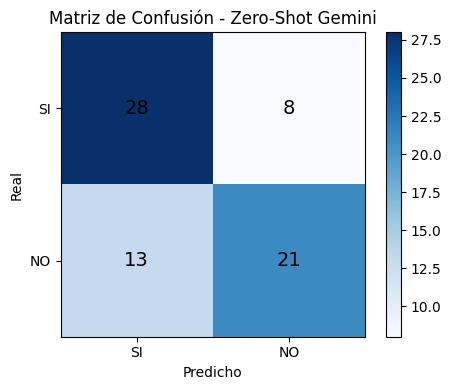

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

cm = np.array([[tp, fn],
               [fp, tn]])

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)

ax.set(xticks=[0, 1],
       yticks=[0, 1],
       xticklabels=["SI", "NO"],
       yticklabels=["SI", "NO"],
       title="Matriz de Confusión - Zero-Shot Gemini",
       ylabel="Real",
       xlabel="Predicho")

# Poner los números en cada celda
for i in range(2):
    for j in range(2):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center", color="black", fontsize=14)

plt.tight_layout()
plt.show()

## 11. Conclusiones

### Resultados obtenidos

| Métrica | Valor |
|---|---|
| **Accuracy global** | **70.00%** |
| Aciertos | 49 / 70 |
| Fallos | 21 / 70 |
| Macro Precision | 70.35% |
| Macro Recall | 69.77% |
| Macro F1 | 69.70% |

### Métricas por clase

| Clase | Precision | Recall | F1 |
|---|---|---|---|
| `SI` | 68.29% | 77.78% | 72.73% |
| `NO` | 72.41% | 61.76% | 66.67% |

### Análisis

- El modelo alcanza un **70% de accuracy** sin haber sido entrenado en este dominio, lo que confirma la viabilidad del enfoque zero-shot como línea base.
- La clase `SI` presenta mejor *recall* (77.78%): el modelo detecta correctamente la mayoría de las posturas válidas.
- La clase `NO` tiene un *recall* inferior (61.76%): **13 imágenes de la clase `NO` se predicen como `SI`** (falsos positivos), siendo este el error más frecuente.
- Las métricas balanceadas entre clases (Macro F1 ≈ 70%) indican que el modelo no está sesgado hacia ninguna clase de forma extrema.

### Próximos pasos

- Refinar la descripción de la clase `NO` en el prompt para reducir falsos positivos.
- Comparar con un enfoque *few-shot* incluyendo ejemplos visuales en el prompt.
- Contrastar con el modelo CNN entrenado desde cero sobre el mismo conjunto de evaluación.